
 Online Retail II

 - Author: Hai Yen Nguyen
 - Date: 2026-07-01

In [ ]:
# Import thư viện sử dụng
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Cấp quyền truy cập file trên google drive
from google.colab import drive
drive.mount('/content/ggdrive')

Drive already mounted at /content/ggdrive; to attempt to forcibly remount, call drive.mount("/content/ggdrive", force_remount=True).


In [ ]:
#Đọc file dữ liệu
df_raw = pd.read_csv('/content/ggdrive/MyDrive/Online_retail_raw/online_retail_II.csv', dtype={'CustomerID': str})
display(df_raw.head())

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


PHẦN 1: EXPLORATORY DATA ANALYSIS - PHÂN TÍCH KHAI PHÁ DỮ LIỆU

1: Nhìn tổng quan dữ liệu

In [ ]:
df_raw.shape #Dữ liệu có bao nhiêu dòng, bao nhiêu cột (Dữ liệu gốc có 1,067,371 dòng và 8 cột )

(1067371, 8)

In [ ]:
df_raw.columns #Các cột trong dữ liệu là những cột nào

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [ ]:
df_raw.head(10) #Xem 10 dòng dữ liệu đầu tiên

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [ ]:
df_raw.sample(10) # Xem 10 dòng dữ liệu ngẫu nhiên

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
98803,498642,21936,RED/WHITE SPOT PICNIC BAG,5,2010-02-22 11:13:00,2.95,16057.0,United Kingdom
173008,505756,82578,KITCHEN METAL SIGN,12,2010-04-26 09:48:00,0.55,14677.0,United Kingdom
976933,575211,22631,CIRCUS PARADE LUNCH BOX,1,2011-11-09 10:39:00,1.95,17377.0,United Kingdom
182312,506708,22029,SPACEBOY BIRTHDAY CARD,12,2010-05-02 14:53:00,0.42,15719.0,United Kingdom
682825,550203,21700,BIG DOUGHNUT FRIDGE MAGNETS,1,2011-04-15 10:37:00,8.29,NaN,United Kingdom
468742,533561,85027L,FRENCH CHATEAU LARGE PLATTER,2,2010-11-18 10:06:00,7.95,16265.0,United Kingdom
541241,537640,85099f,JUMBO BAG STRAWBERRY,8,2010-12-07 15:31:00,5.06,NaN,United Kingdom
66978,495355,84839,SWEETHEART KEY CABINET,2,2010-01-24 11:26:00,6.75,12916.0,United Kingdom
573463,540458,22352,LUNCH BOX WITH CUTLERY RETROSPOT,6,2011-01-07 12:28:00,2.55,12501.0,Germany
270820,515621,37450,CERAMIC CAKE BOWL + HANGING CAKES,18,2010-07-14 09:54:00,2.55,14258.0,United Kingdom


In [ ]:
df_raw.info() #Kiểu dữ liệu từng cột, cột nào bị thiếu

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


Cột Customer ID chỉ có 824,364 giá trị , giá trị NA chiếm khoảng 22% là một số lượng lớn

In [ ]:
df_raw.describe() #Thống kê mô tả dữ liệu

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


Quantity có giá trị min âm ,Price có giá trị min âm
Điều này là không bình thường vì khách hàng không thể mua sản phẩm số lượng và giá âm

2: Kiểm tra chất lượng - "Dữ liệu bẩn ở đâu"

In [ ]:
df_raw.isnull().sum() # Cột nào thiếu bao nhiêu giá trị


,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


In [ ]:
df_raw.isnull().sum()/ len(df_raw)*100 # Đổi ra % cho dễ trình bày

,0
Invoice,0.000000
StockCode,0.000000
Description,0.410541
Quantity,0.000000
InvoiceDate,0.000000
Price,0.000000
Customer ID,22.766873
Country,0.000000


Cột Description thiếu 4382 giá trị chiếm 0.41 % trên tổng
Cột Customer ID thiếu 243,007 giá trị chiếm khoảng 22% trên tổng - phần trăm thiếu lớn

In [ ]:
df_raw.duplicated().sum() # bao nhiêu dòng trùng lặp hoàn toàn

np.int64(34335)

Có 34,335 dòng trùng lặp hoàn toàn

In [ ]:
#Quantity có giá trị âm, kiểm tra hóa đơn bắt đầu bằng chữ C - Cancelled Invoice

In [ ]:
df_raw['Invoice'] = df_raw["Invoice"].astype(str) # Cột Invoice có cả kiểu dữ liệu số và chữ nên ép tất cả về kiểu str

In [ ]:
#Tạo một cột mới tên IsCancelled trong df_raw để đánh dấu các đơn hàng bắt đầu bằng "C" ( C - các đơn hàng bị hủy)
#Đơn hàng bắt đầu bằng C cột IsCancelled (những đơn hàng này là đơn hủy của khách hàng ) trả về giá trị TRUE , nếu không trả về FALSE
df_raw['IsCancelled']= df_raw['Invoice'].str.startswith('C')
df_raw.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancelled
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,False
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom,False
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom,False
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom,False


Cột IsCancelled nếu Invoice bắt đầu bằng chữ C sẽ trả về kết quả TRUE , đây là những đơn khách hủy -> có thể tạo bảng danh sách hoàn hàng để phân tích hoàn hàng và  xóa đi khi phân tích sales, RFM

In [ ]:
# Kiểm chứng các đơn hàng hủy ("C") và đơn hàng có quantity âm
pd.crosstab(df_raw['IsCancelled'],df_raw['Quantity']<=0)

Quantity,False,True
IsCancelled,,
False,1044420,3457
True,1,19493


Nhận xét :
- Số đơn hàng không phải là hóa đơn hủy và có quantity > 0 là 1,044,420
- Số đơn hàng là đơn hủy/hoàn hàng và có quantity < 0 là 19,493 đơn --> tách thành một bảng riêng để phân tích hoàn/hủy (nếu cần) , loại bỏ đi trong
- Số đơn hàng không phải là đơn hủy/hoàn hàng nhưng quantity <= 0 là 3457 đơn --> xem mô tả những đơn hàng này
- Số đơn hàng là hủy nhưng có quantity dương là 1 đơn --> xem mô tả đơn hàng này

In [ ]:
# Kiểm tra nhóm không phải đơn hủy/hoàn hàng và quantity <=0
df_adjust = df_raw[(df_raw['IsCancelled']==False)&(df_raw['Quantity']<=0)].copy()
df_adjust.shape


(3457, 9)

In [ ]:
# Xem mô tả bảng nhóm không phải đơn hủy/hoàn và quantity <=0
df_adjust.describe()

,Quantity,Price,Customer ID
count,3457.000000,3457.0,0.0
mean,-165.775239,0.0,NaN
std,673.108503,0.0,NaN
min,-9600.000000,0.0,NaN
25%,-82.000000,0.0,NaN
50%,-26.000000,0.0,NaN
75%,-8.000000,0.0,NaN
max,-1.000000,0.0,NaN


In [ ]:
# Xem 10 dòng đầu của bảng adjust
df_adjust.head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancelled
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom,False
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom,False
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom,False
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom,False
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom,False
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom,False
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom,False
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom,False
4538,489820,21133,invcd as 84879?,-720,2009-12-02 13:23:00,0.0,NaN,United Kingdom,False
4566,489821,85049G,NaN,-240,2009-12-02 13:25:00,0.0,NaN,United Kingdom,False


Bảng df_adjust có 3457 dòng với giá = 0 và phần mô tả gồm damage, missing,lost,NA --> đây là bút toán điều chỉnh trong dữ liệu

In [ ]:
# Kiểm tra 1 dòng là hóa đơn hủy nhưng quantity dương
df_raw[(df_raw['IsCancelled']==True)& (df_raw['Quantity']>0)]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancelled
76799,C496350,M,Manual,1,2010-02-01 08:24:00,373.57,NaN,United Kingdom,True


Mô tả của dòng này là Manual là bước tay, có thể do nhầm lần --> loại bỏ dòng này trong phân tích tiếp theo

Nhận xét: Nhìn vào 10 dòng đầu thiếu Customer ID trong bảng df_sales thì đây là những giao dịch thật với số lượng nhỏ --> đây là giao dịch thật của những khách lẻ, khách vãng lai .
- Khi phân tích không có định danh khách hàng sẽ không phân tích được RFM và Cohort nên sẽ tách ra một bảng loại bỏ khách không có Customer ID cho phân tích RFM và Cohort.
- Không có Customer ID nhưng vẫn là những giao dịch thật, thu được tiền nên vẫn giữ lại ở bảng df_sales để phân tích doanh thu lợi nhuận

Tóm tắt chất lượng dữ liệu và đưa ra quyết định làm sạch:
- Loại bỏ các dòng trùng lặp hoàn toàn
- Hóa đơn hủy - bắt đầu bằng "C" : tách thành một bảng hủy/hoàn riêng sử dụng cho phân tích hủy/hoàn (đã tách ra bảng df_adjust) và loại bỏ trong phân tích sales,RFM(dự án đang làm)
- Loại bỏ 1 dòng là bút toán Manual không ảnh hưởng nhiều đến phân tích
- Customer ID thiếu vẫn giữ nguyên ở bảng df_sales để phân tích sales
- Customer ID thiếu không định danh được khách hàng sẽ loại bỏ trong phân tích RFM,Cohort --> tách ra bảng df_rfm riêng

Làm sạch dữ liệu

In [ ]:
#Loại bỏ những dòng trùng lặp hoàn toàn tách ra bảng df còn 1033036 dòng
df= df_raw.drop_duplicates().copy()
print('Loại bỏ các dòng trùng lặp hoàn toàn còn lại:',len(df))

Loại bỏ các dòng trùng lặp hoàn toàn còn lại: 1033036


In [ ]:
# Tạo bảng df_cancelled độc lập với .copy() để xử lý độc lập trong một phiên làm việc
df_cancelled = df[df['IsCancelled']&(df['Quantity']<0)].copy()
df_cancelled

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancelled
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,True
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,True
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,True
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,True
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,True
...,...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom,True
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom,True
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom,True
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,True


In [ ]:
#Tạo bảng df_sales gồm những đơn hàng không phải đơn hủy và có quality dương
df_sales = df[(df['IsCancelled']==False)&(df['Quantity']>0)].copy()
df_sales

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancelled
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False
...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,False
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,False
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,False
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,False


In [ ]:
#Tách bảng bước toán điều chỉnh
df_adjust = df[(df['IsCancelled']==False)&(df['Quantity']<=0)].copy()
df_adjust

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancelled
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom,False
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom,False
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom,False
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom,False
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom,False
...,...,...,...,...,...,...,...,...,...
1060794,581210,23395,check,-26,2011-12-07 18:36:00,0.0,NaN,United Kingdom,False
1060796,581212,22578,lost,-1050,2011-12-07 18:38:00,0.0,NaN,United Kingdom,False
1060797,581213,22576,check,-30,2011-12-07 18:38:00,0.0,NaN,United Kingdom,False
1062371,581226,23090,missing,-338,2011-12-08 09:56:00,0.0,NaN,United Kingdom,False


In [ ]:
#Kiểm chứng lại
len(df) == len(df_cancelled) + len(df_adjust) + len(df_sales)

False

In [ ]:
# Tính tổng số dòng 3 bảng đã tách df_cancelled, df_adjust, df_sales
len(df_cancelled) + len(df_adjust) + len(df_sales)

1033035

Tổng còn thiếu 1 dòng - đã được phân tích ở trên là dòng Manual bước toán tay bị lỗi nên bỏ ra tổng df và 3 bảng + 1 dòng manual đã trùng khớp nhau .
Đầu giờ chiều lọc và tạo bảng để phân tích RFM (bỏ những dòng không có CustomerID là xong phần cleaning )

In [ ]:
# Tách bảng df_rfm chỉ lấy những dòng trong df_sales có Customer ID
df_rfm = df_sales[df_sales['Customer ID'].notna()].copy()
df_rfm

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancelled
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False
...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,False
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,False
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,False
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,False


In [ ]:
# Xem df_rfm có giá = 0 không?
zero =df_rfm[df_rfm['Price']==0]
zero.sample(20)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancelled
971586,574879,22625,RED KITCHEN SCALES,2,2011-11-07 13:22:00,0.0,13014.0,United Kingdom,False
47126,493761,79320,FLAMINGO LIGHTS,24,2010-01-06 14:54:00,0.0,14258.0,United Kingdom,False
655649,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,2011-03-23 10:25:00,0.0,13239.0,United Kingdom,False
582135,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,2011-01-13 15:10:00,0.0,15107.0,United Kingdom,False
89084,497819,TEST001,This is a test product.,5,2010-02-12 14:58:00,0.0,14103.0,United Kingdom,False
962422,574252,M,Manual,1,2011-11-03 13:24:00,0.0,12437.0,France,False
808373,561669,22960,JAM MAKING SET WITH JARS,11,2011-07-28 17:09:00,0.0,12507.0,Spain,False
327801,521375,22202,MILK PAN PINK RETROSPOT,3,2010-09-05 11:58:00,0.0,12647.0,Germany,False
111348,500073,21662,VINTAGE GLASS COFFEE CADDY,1,2010-03-04 11:44:00,0.0,13047.0,United Kingdom,False
32916,492079,85042,ANTIQUE LILY FAIRY LIGHTS,8,2009-12-15 13:49:00,0.0,15070.0,United Kingdom,False


Kiểm tra bảng df_rfm vẫn có price = 0 , xem trong phần mô tả bao gồm test product, manual và tên sản phẩm thật (có thể là hàng tặng ) --> loại bỏ những dòng này ra khỏi df_rfm --> bảng df_rfm_base

In [ ]:
df_rfm_base = df_rfm[df_rfm['Price']>0].copy()
df_rfm_base

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancelled
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False
...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,False
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,False
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,False
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,False


In [ ]:
#Xem trong bảng df_sales còn lẫn Price =0 không?
df_sales_0 = df_sales[df_sales['Price']==0]
df_sales_0

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancelled
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom,False
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom,False
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.0,16126.0,United Kingdom,False
5904,489861,DOT,DOTCOM POSTAGE,1,2009-12-02 14:50:00,0.0,NaN,United Kingdom,False
6378,489882,35751C,NaN,12,2009-12-02 16:22:00,0.0,NaN,United Kingdom,False
...,...,...,...,...,...,...,...,...,...
1060795,581211,22142,check,14,2011-12-07 18:36:00,0.0,NaN,United Kingdom,False
1062442,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom,False
1063965,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,NaN,United Kingdom,False
1063966,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,NaN,United Kingdom,False


Trong bảng df_sales vẫn còn 2621 dòng Price = 0 --> loại bỏ những dòng này trong df_sales

In [ ]:
df_sales_final = df_sales[df_sales['Price']>0].copy()
df_sales_final

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancelled
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False
...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,False
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,False
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,False
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,False


Kiểm tra , làm sạch ở tầng khách hàng

In [ ]:
# Tính doanh thu cho bảng hoàn
df_cancelled['Revenue'] = df_cancelled['Quantity']*df_cancelled['Price']
df_cancelled.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancelled,Revenue
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,True,-35.4
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,True,-9.9
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,True,-17.0
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,True,-12.6
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,True,-35.4


In [ ]:
# Tính doanh thu cho bảng df_sales
df_sales_final['Revenue'] = df_sales_final['Quantity']*df_sales_final['Price']
df_sales_final.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancelled,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,30.0


In [ ]:
# Tính tổng tiền mua và tổng tiền hoàn của từng khách
buy = df_sales_final.groupby('Customer ID')['Revenue'].sum()
buy

,Revenue
Customer ID,
12346.0,77556.46
12347.0,4921.53
12348.0,2019.40
12349.0,4428.69
12350.0,334.40
...,...
18283.0,2664.90
18284.0,461.68
18285.0,427.00


In [ ]:
# Tổng tiền hoàn của mỗi khách
returns = df_cancelled.groupby('Customer ID')['Revenue'].sum().abs()
returns

,Revenue
Customer ID,
12346.0,77608.20
12349.0,24.15
12352.0,960.63
12359.0,221.05
12360.0,40.00
...,...
18280.0,15.70
18282.0,1.45
18284.0,25.00


In [ ]:
# Ghép thành sổ đối soát
audit = pd.DataFrame({'Buy': buy,'Return': returns}).fillna(0)
audit
# Buy trong sales có 5878 dòng (khách) trong khi returns có 2572 dòng do có những khách mua mà không hủy
# khi ghép thành bảng audit những khách này cần điền returns là 0 để tránh lỗi NA

,Buy,Return
Customer ID,,
12346.0,77556.46,77608.20
12347.0,4921.53,0.00
12348.0,2019.40,0.00
12349.0,4428.69,24.15
12350.0,334.40,0.00
...,...,...
18283.0,2664.90,0.00
18284.0,461.68,25.00
18285.0,427.00,0.00


In [ ]:
#Tính ra 2 chỉ số chuẩn đoán
audit['Return Rate'] = audit['Return']/audit['Buy']
audit

,Buy,Return,Return Rate
Customer ID,,,
12346.0,77556.46,77608.20,1.000667
12347.0,4921.53,0.00,0.000000
12348.0,2019.40,0.00,0.000000
12349.0,4428.69,24.15,0.005453
12350.0,334.40,0.00,0.000000
...,...,...,...
18283.0,2664.90,0.00,0.000000
18284.0,461.68,25.00,0.054150
18285.0,427.00,0.00,0.000000


In [ ]:
audit['Net'] = audit['Buy'] - audit['Return']
audit

,Buy,Return,Return Rate,Net
Customer ID,,,,
12346.0,77556.46,77608.20,1.000667,-51.74
12347.0,4921.53,0.00,0.000000,4921.53
12348.0,2019.40,0.00,0.000000,2019.40
12349.0,4428.69,24.15,0.005453,4404.54
12350.0,334.40,0.00,0.000000,334.40
...,...,...,...,...
18283.0,2664.90,0.00,0.000000,2664.90
18284.0,461.68,25.00,0.054150,436.68
18285.0,427.00,0.00,0.000000,427.00


Chú ý: Buy có 5878 khách - những người có ít nhất 1 giao dịch mua, Return có một danh sách khác - những người có ít nhất 1 giao dịch hoàn . 5939 - 5878 = 61 khách có hoàn hàng nhưng không có giao dịch mua --> với những khách này Buy được fillna(0) .
- Tại sao : Hoàn hàng mua ngoài khung thời gian dataset hoặc giao dịch mua của họ bị pineline lọc bỏ
- Hệ quả cần xử lý: Với 61 khách này, Buy = 0 nên phép chia Return/0 ra vô cực

In [ ]:
# Lọc ra danh sách khách "phantom"(ma)
phantom = audit[audit['Return Rate']>=0.95].index
phantom


Index([12346.0, 12382.0, 12467.0, 12503.0, 12558.0, 12607.0, 12706.0, 12768.0,
       12773.0, 12896.0,
       ...
       17592.0, 17632.0, 17641.0, 17645.0, 17661.0, 17755.0, 17943.0, 18023.0,
       18072.0, 18274.0],
      dtype='float64', name='Customer ID', length=103)

Ngưỡng 0.95 thay vì 1.0 chừa chỗ cho khách hoàn gần hết nhưng sót vài món lặt vặt - vẫn coi là khách ma, khách ảo (không tạo ra doanh thu thực)

In [ ]:
# Loại khách phantom ra khỏi bảng bán hàng
df_sales_f_clean = df_sales_final[~df_sales_final['Customer ID'].isin(phantom)].copy()
df_sales_f_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancelled,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,30.00
...,...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,False,12.60
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,False,16.60
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,False,16.60
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,False,14.85


Customer 12346 - Phantom VIP

- Invoice 541431 (18/1/2011, 10:01): mua 74,215 chiếc MEDIUM CERAMIC TOP STORAGE JAR
  (~£77K) — đơn hàng lớn nhất toàn dataset.
- Invoice C541433 (10:17 cùng ngày — **16 phút sau**): hủy toàn bộ, đúng số lượng.
- Pipeline loại dòng hủy nhưng giữ dòng mua → trong RFM, khách này hiện lên như
  VIP số 1 **giả**: Monetary ~£77K nhưng doanh thu ròng ≈ 0.
- Rủi ro nếu bỏ qua: kéo lệch thang điểm Monetary (qcut), và K-Means có thể sinh
  một cụm chỉ để chứa outlier này.
- **Phương án gọn (đã chọn, vì deadline):** xử lý ở tầng RFM — sau khi tính bảng
  RFM, rà top khách theo Monetary, đối chiếu tỷ lệ hoàn trả; khách hoàn ~100% bị
  loại khỏi phân khúc, có ghi chú.
- Phương án chuẩn : Monetary = doanh thu ròng (mua − hoàn,
  merge từ df_returns theo Customer ID).

In [ ]:
# Tính lại bảng df_rfm_base bỏ phantom customer
df_rfm_base_clean = df_rfm_base[~df_rfm_base['Customer ID'].isin(phantom)].copy()
df_rfm_base_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancelled
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False
...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,False
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,False
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,False
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,False


Chốt các bảng sạch vào phần phân tích thống kê mô tả và RFM là :
- df_sales_f_clean (1,007,487 dòng)
- df_rfm_base_clean (778,999 dòng)

3 : Thống kê mô tả từng chiều

In [ ]:
# Thống kê mô tả trên bảng df_sales_f_clean
df_sales_f_clean.describe()

,Quantity,Price,Customer ID,Revenue
count,1.007487e+06,1.007487e+06,778999.000000,1.007487e+06
mean,1.095600e+01,4.022132e+00,15321.043397,1.996521e+01
std,6.734245e+01,4.683144e+01,1695.375133,8.000400e+01
min,1.000000e+00,1.000000e-03,12347.000000,1.000000e-03
25%,1.000000e+00,1.250000e+00,13973.500000,4.130000e+00
50%,4.000000e+00,2.100000e+00,15248.000000,1.008000e+01
75%,1.200000e+01,4.130000e+00,16794.000000,1.770000e+01
max,1.915200e+04,2.511109e+04,18287.000000,2.511109e+04


In [ ]:
# Bán sang bao nhiêu quốc gia ?
df_sales_f_clean['Country'].nunique()
print('Bán sang',df_sales_f_clean['Country'].nunique(),'quốc gia')

Bán sang 43 quốc gia


In [ ]:
# 10 nước nhiều giao dịch nhất
df_sales_f_clean['Country'].value_counts().head(10)
print('10 nước nhiều giao dịch nhất là:',df_sales_f_clean['Country'].value_counts().head(10))

10 nước nhiều giao dịch nhất là: Country
United Kingdom    925753
EIRE               17154
Germany            16432
France             13639
Netherlands         5085
Spain               3660
Switzerland         3122
Belgium             3055
Portugal            2464
Australia           1789
Name: count, dtype: int64


In [ ]:
# Tổng có bao nhiêu khách hàng
df_sales_f_clean['Customer ID'].nunique()
print('Tổng có',df_sales_f_clean['Customer ID'].nunique(),'khách hàng')

Tổng có 5836 khách hàng


In [ ]:
# Tổng có bao nhiêu sản phẩm
df_sales_f_clean['StockCode'].nunique()
print('Tổng có',df_sales_f_clean['StockCode'].nunique(),'sản phẩm')

Tổng có 4914 sản phẩm


In [ ]:
# So sánh mean và median doanh số
df_sales_f_clean['Revenue'].describe()

,Revenue
count,1.007487e+06
mean,1.996521e+01
std,8.000400e+01
min,1.000000e-03
25%,4.130000e+00
50%,1.008000e+01
75%,1.770000e+01
max,2.511109e+04


Nhận xét:
- Doanh số có giá trị trung bình (mean) là 19.97 và giá trị trung vị (median-50%) là 10.08 --> phân phối doanh thu lệch phải (right-skewed) do vài đơn lớn kéo trung bình lên (bộ dữ liệu này gồm cả wholesalers) nên giá trị median đáng tin cậy hơn trong việc thể hiện doanh thu trung bình mỗi đơn hàng (đơn hàng điển hình).
- Độ lệch chuẩn của doanh số là 80 - giá trị khá cao chứng tỏ dữ liệu có giá trị tương đối xa nhau


In [ ]:
# Xem outliers
Q1, Q3 = df_sales_f_clean['Revenue'].quantile([0.25,0.75])
IQR = Q3-Q1
upper = Q3 + 1.5*IQR
outliers_iqr = df_sales_f_clean[df_sales_f_clean['Revenue']> upper]
outliers_iqr

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancelled,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,100.80
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,False,39.60
...,...,...,...,...,...,...,...,...,...,...
1067327,581583,85038,6 CHOCOLATE LOVE HEART T-LIGHTS,36,2011-12-09 12:23:00,1.85,13777.0,United Kingdom,False,66.60
1067328,581584,20832,RED FLOCK LOVE HEART PHOTO FRAME,72,2011-12-09 12:25:00,0.72,13777.0,United Kingdom,False,51.84
1067329,581584,85038,6 CHOCOLATE LOVE HEART T-LIGHTS,48,2011-12-09 12:25:00,1.85,13777.0,United Kingdom,False,88.80
1067353,581586,21217,RED RETROSPOT ROUND CAKE TINS,24,2011-12-09 12:49:00,8.95,13113.0,United Kingdom,False,214.80


In [ ]:
# Tính tỷ lệ phần trăm outliers
len(outliers_iqr)/len(df_sales_f_clean)*100
print('Tỷ lệ phần trăm outliers là:',len(outliers_iqr)/len(df_sales_f_clean)*100)

Tỷ lệ phần trăm outliers là: 8.420356788722833


4 - Phân tích theo nhóm và thời gian

In [ ]:
# Doanh thu theo quốc gia - top 10 quốc gia có doanh thu cao nhất
doanh_thu_quoc_gia =df_sales_f_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
doanh_thu_quoc_gia.head(10)

,Revenue
Country,
United Kingdom,1.706594e+07
EIRE,6.587673e+05
Netherlands,5.540381e+05
Germany,4.250197e+05
France,3.504561e+05
Australia,1.692835e+05
Spain,1.072065e+05
Switzerland,1.006856e+05
Sweden,9.186982e+04


In [ ]:
# Top 10 sản phẩm bán chạy (theo số lượng)
top_10_sp =df_sales_f_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
top_10_sp

,Quantity
Description,
WORLD WAR 2 GLIDERS ASSTD DESIGNS,105707
WHITE HANGING HEART T-LIGHT HOLDER,94652
ASSORTED COLOUR BIRD ORNAMENT,80082
JUMBO BAG RED RETROSPOT,77689
BROCADE RING PURSE,70369
PACK OF 60 PINK PAISLEY CAKE CASES,56061
60 TEATIME FAIRY CAKE CASES,54004
SMALL POPCORN HOLDER,48561
PACK OF 72 RETROSPOT CAKE CASES,48132


In [ ]:
# Doanh thu theo tháng - có mùa vụ không?
# Đổi kiểu InvoiceDate sang datetime
df_sales_f_clean['InvoiceDate'] = pd.to_datetime(df_sales_f_clean['InvoiceDate'])

In [ ]:
# Tính doanh thu tháng
doanh_thu_thang = df_sales_f_clean.set_index('InvoiceDate')['Revenue'].resample('ME').sum()
doanh_thu_thang

,Revenue
InvoiceDate,
2009-12-31,809031.130
2010-01-31,645960.952
2010-02-28,551504.726
2010-03-31,805695.681
2010-04-30,678573.202
2010-05-31,656455.250
2010-06-30,747226.750
2010-07-31,648810.270
2010-08-31,695251.910


In [ ]:
# Gía trị mỗi hóa đơn

invoice_value=df_sales_f_clean.groupby('Invoice')['Revenue'].sum()
invoice_value

,Revenue
Invoice,
489434,505.30
489435,145.80
489436,630.33
489437,310.75
489438,2286.24
...,...
581584,140.64
581585,329.05
581586,339.20


In [ ]:
# Tổng doanh thu của tất cả các quốc gia
tong_doanh_thu = df_sales_f_clean['Revenue'].sum()
print('Tổng doanh thu là',tong_doanh_thu)

Tổng doanh thu là 20114684.718


In [ ]:
# Tính phần trăm doanh thu theo quốc gia
phan_tram = df_sales_f_clean.groupby('Country')['Revenue'].sum()/tong_doanh_thu * 100
phan_tram

,Revenue
Country,
Australia,0.841591
Austria,0.117392
Bahrain,0.015460
Belgium,0.325075
Bermuda,0.006230
Brazil,0.007019
Canada,0.024276
Channel Islands,0.221845
Cyprus,0.123541


In [ ]:
# Sắp xếp giảm dần và lấy top10
phan_tram_top10 = phan_tram.sort_values(ascending = False).head(10)
phan_tram_top10

,Revenue
Country,
United Kingdom,84.843179
EIRE,3.275057
Netherlands,2.754396
Germany,2.112982
France,1.742290
Australia,0.841591
Spain,0.532976
Switzerland,0.500558
Sweden,0.456730


Nhận xét:
- United Kingdom chiếm phần trăm doanh thu cao nhất khoảng 85% doanh thu
- Có thể nhìn thấy doanh thu tăng cao vào tháng cuối năm 10,11( mùa giáng sinh )
- Chú ý: dataset kết thúc vào 9/12/2011 nên tháng 12 trông thấp giả tạo

In [ ]:
doanh_thu_thang.sort_values(ascending=False)

,Revenue
InvoiceDate,
2011-11-30,1503345.040
2010-11-30,1463887.102
2010-10-31,1153849.750
2011-10-31,1149678.020
2011-09-30,1055498.552
2010-09-30,905930.501
2010-12-31,821452.730
2009-12-31,809031.130
2010-03-31,805695.681


5 - Trực quan hóa


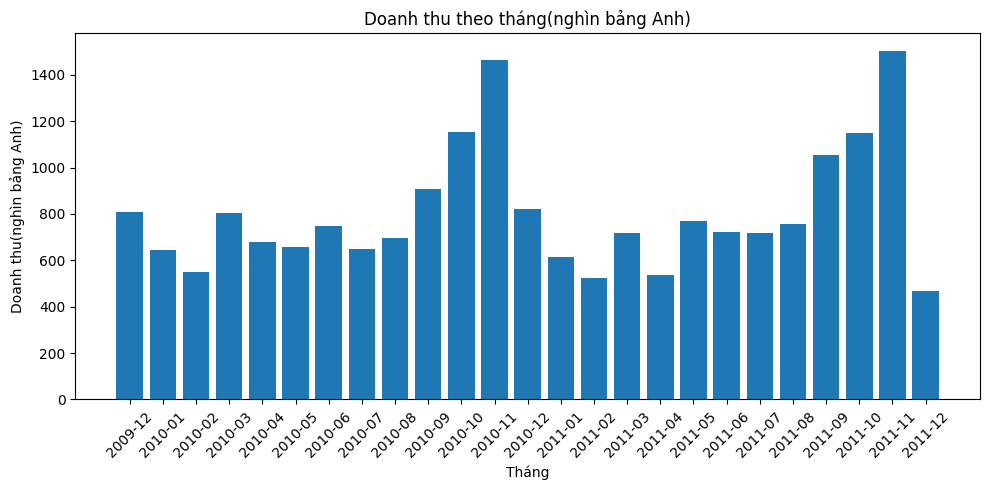

In [ ]:
# Biểu đồ 1: Bar chart - Doanh thu theo tháng
plt.figure(figsize=(10,5))
plt.bar(doanh_thu_thang.index.strftime('%Y-%m'),doanh_thu_thang.values/1000)#Chia cho 1000 cho gọn trục
plt.title('Doanh thu theo tháng(nghìn bảng Anh)')
plt.xlabel('Tháng')
plt.ylabel('Doanh thu(nghìn bảng Anh)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Nhận xét:
- Doanh thu cao nhất vào tháng 9-11 vào mùa Giangs sinh , khách buôn nhập hàng sớm
- Doanh thu tháng 12/2011 thấp giả tạo do dataset kết thúc đầu tháng 12

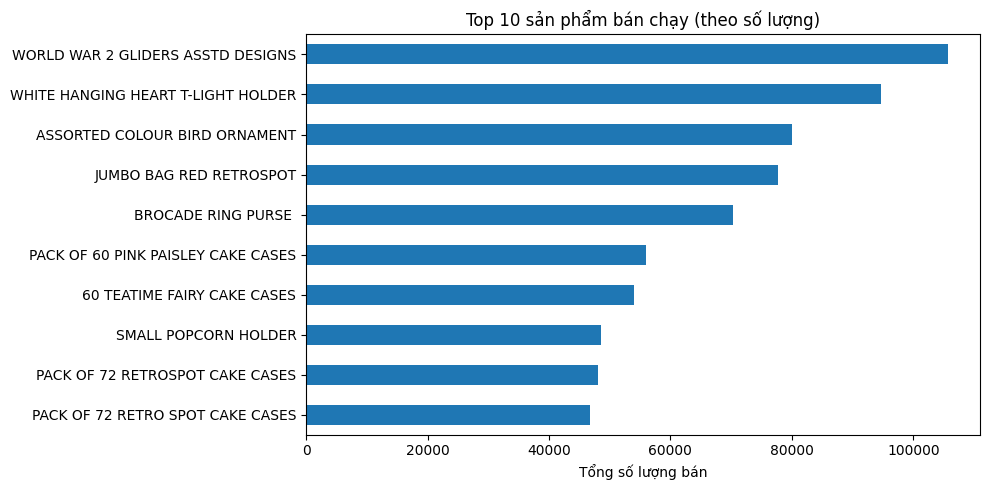

In [ ]:
# Biểu đồ 2: Bar chart ngang: Top 10 sản phẩm bán chạy
plt.figure(figsize =(10,5))
top_10_sp.sort_values().plot(kind='barh')
plt.title('Top 10 sản phẩm bán chạy (theo số lượng)')
plt.xlabel('Tổng số lượng bán')
plt.ylabel('') #tên sản phẩm đã dài rồi, bỏ nhãn trục cho thoáng
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

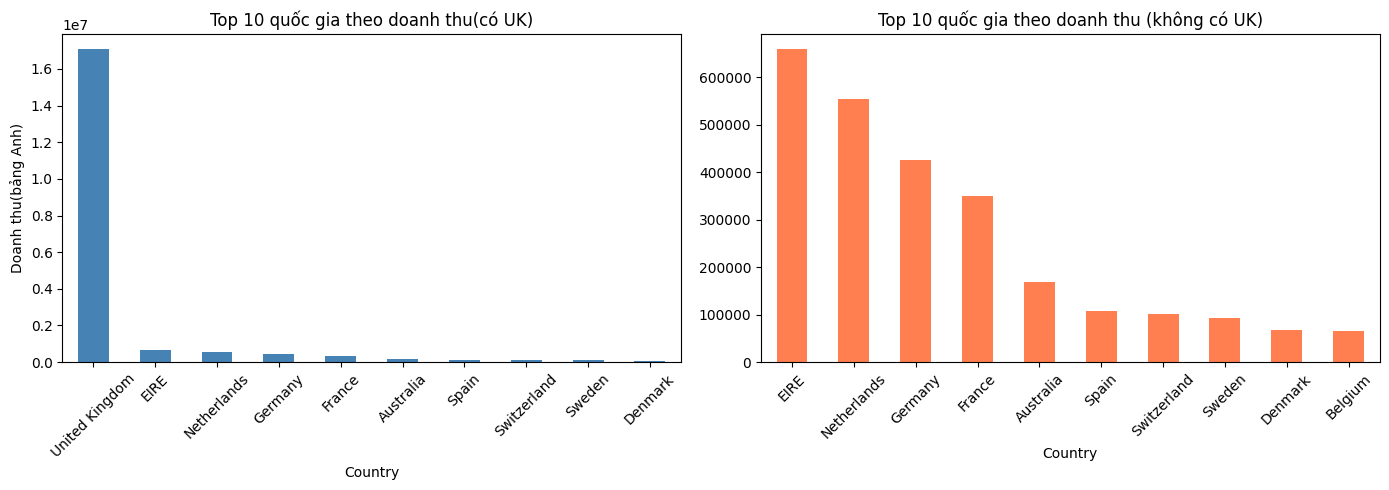

In [ ]:
# Biểu đồ 3 : Top 10 quốc gia có doanh thu cao nhất: có UK và không có UK
fig, axes = plt.subplots(1,2,figsize=(14,5))
# Bên trái: có UK - thấy mức độ áp đảo
doanh_thu_quoc_gia.head(10).plot(kind='bar',ax =axes[0],color='steelblue')
axes[0].set_title('Top 10 quốc gia theo doanh thu(có UK)')
axes[0].set_ylabel('Doanh thu(bảng Anh)')
axes[0].tick_params(axis='x',rotation=45)
# Bên phải : bỏ UK - thấy bức tranh các nước còn lại
doanh_thu_quoc_gia.drop('United Kingdom').head(10).plot(kind='bar', ax=axes[1],color='coral')
axes[1].set_title('Top 10 quốc gia theo doanh thu (không có UK)')
axes[1].tick_params(axis='x',rotation=45)

plt.tight_layout()
plt.show

Nhận xét:
- Doanh thu UK gấp khoảng 26 lần nước thứ nhì nên các quốc gia còn lại chỉ còn là các chấm nhỏ ta có hình bên trái thể hiện " UK áp đảo cỡ nào"
- Hình bên phải bỏ UK --> thấy rõ thứ hạng các nước còn lại

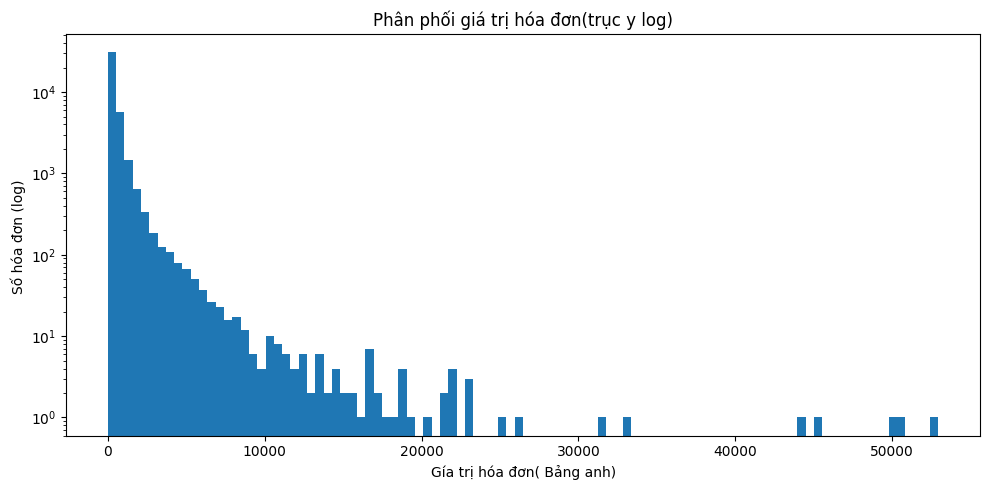

In [ ]:
# Biểu đồ 4: Histogram - phân phối giá trị hóa đơn (log)
plt.figure(figsize=(10,5))
plt.hist(invoice_value,bins=100)
plt.yscale('log')
plt.title('Phân phối giá trị hóa đơn(trục y log)')
plt.xlabel('Gía trị hóa đơn( Bảng anh)')
plt.ylabel('Số hóa đơn (log) ')
plt.tight_layout()
plt.show()

In [ ]:
# In bảng thống kê 8 chỉ số quen thuộc trên giá trị hóa đơn
print(invoice_value.describe().round(2))

count    39999.00
mean       502.88
std       1141.96
min          0.19
25%        149.92
50%        302.22
75%        492.91
max      52940.94
Name: Revenue, dtype: float64


Nhận xét:
- Hóa đơn điển hình (median) khoảng 300-350 bảng Anh, giá trị trung bình mean là 502.88 với max lên tới hàng chục nghìn (52,940.94) - phân phối lệch phải ở cấp hóa đơn, nhất quán với kết luận ở từng dòng giao dịch.

PHẦN 2: SEGMENTATION - PHÂN LOẠI KHÁCH HÀNG THEO HÀNH VI MUA VỚI MÔ HÌNH PHÂN TÍCH RFM (RECENCY,FREQUENCY,MONETARY)


Giới thiệu:
RFM là một mô hình phân tích phân loại khách hàng theo hành vi mua nổi tiếng. Bên dưới đây là định nghĩa của từng tham số trong RFM.
- Recency: Khoảng thời gian từ lần giao dịch cuối cùng ( trong bộ dữ liệu này ngày 10-12-2011 là ngày tham chiếu - sau ngày cuối cùng của data set 9-12-2011)
- Frequency: Tổng số lần giao dịch của từng khách hàng
- Monetary: Tổng số tiền khách đã mua

K1 : Chuẩn bị: Doanh thu và ngày tham chiếu (ngày 10-12-2011)

In [ ]:
# K1: Chuẩn bị: Doanh thu và ngày tham chiếu ( dự đoán ngày 10-12-2011)
df_rfm_base_clean # viết gọn tên bảng thành rfm



,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancelled
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False
...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,False
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,False
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,False
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,False


In [ ]:
#Tạo cột Revenue - doanh thu trong bảng rfm
df_rfm_base_clean['Revenue'] = df_rfm_base_clean['Quantity']*df_rfm_base_clean['Price']
# Chuyển dữ liệu cột InvoiceDate sang dạng ngày tháng
df_rfm_base_clean['InvoiceDate']=pd.to_datetime(df_rfm_base_clean['InvoiceDate'])
#Ngày tham chiếu (dự đoán 10-12-2011)
snapshot_date = df_rfm_base_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print('Ngày tham chiếu là:',snapshot_date)

Ngày tham chiếu là: 2011-12-10 12:50:00


K2 — Tính R, F, M: trái tim của cả bài, một lệnh groupby. Logic từng chiều: Recency = số ngày từ lần mua gần nhất đến ngày mốc (lấy max ngày của khách, trừ ngược); Frequency = số đơn duy nhất (nunique — nhớ bài duplicates: đếm dòng là sai); Monetary = tổng Revenue.

In [ ]:
bang_rfm = df_rfm_base_clean.groupby('Customer ID').agg(
    Recency =('InvoiceDate',lambda x: (snapshot_date -x.max()).days),
    Frequency = ('Invoice','nunique'),
    Monetary = ('Revenue','sum')
    )
bang_rfm

,Recency,Frequency,Monetary
Customer ID,,,
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40
12351.0,375,1,300.93
...,...,...,...
18283.0,4,22,2664.90
18284.0,432,1,461.68
18285.0,661,1,427.00


In [ ]:
bang_rfm['R'] = pd.qcut(bang_rfm['Recency'], 4, labels=[4, 3, 2, 1]).astype(int)   # ngược
bang_rfm['F'] = pd.qcut(bang_rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
bang_rfm['M'] = pd.qcut(bang_rfm['Monetary'], 4, labels=[1, 2, 3, 4]).astype(int)

bang_rfm['RFM_Score'] = bang_rfm['R'].astype(str) + bang_rfm['F'].astype(str) + bang_rfm['M'].astype(str)
print(bang_rfm['RFM_Score'].value_counts().head(10))

RFM_Score
444    644
111    565
344    354
211    260
233    227
333    227
222    218
122    209
433    208
112    159
Name: count, dtype: int64


In [ ]:
# Nghiệm thu : kiểm tra xem 4 nhóm bằng nhau không?
for col in ['R','F','M']:
  print(bang_rfm[col].value_counts().sort_index())

R
1    1448
2    1461
3    1465
4    1462
Name: count, dtype: int64
F
1    1459
2    1459
3    1459
4    1459
Name: count, dtype: int64
M
1    1459
2    1459
3    1459
4    1459
Name: count, dtype: int64


Ba thang điểm chia ~25%/nhóm. F và M đều tuyệt đối (F nhờ rank, M giá trị liên tục); R lệch tối đa 17 khách (~0.3%) do Recency là số ngày nguyên trùng giá trị — qcut giữ nguyên cụm khách đồng giá trị nên không xé đôi tại vạch phân vị. Trong dung sai, nghiệm thu đạt.

K3 - Gán nhãn phân khúc (rule-based, lưới R x F)

Vai trò 3 trục : R ="Khách còn sống không?"(có nên liên hệ). F = "Có thói quen quay lại không?"(kiểu quan hệ). M="Đáng giá bao nhiêu"(mức đầu tư). RxF đặt tên phân khúc; M làm lớp phụ ưu tiên ngân sách.

In [ ]:
# Gán nhãn phân khúc
def gan_nhan(row):
  r,f = int(row['R']), int(row['F']) # ép category -> int mới so sánh được
  if r ==4 and f ==4:
    return 'Champions'
  elif r >=3 and f >=3 :
    return 'Loyal Customers'
  elif r ==4 and f <=2:
    return 'New Customer'
  elif r ==3 and f <=2:
    return 'Potential Loyalist'
  elif r <= 2 and f >=3:
    return 'At Risk'# Từng trung thành , đang rời xa - ưu tiên Win-back
  elif r ==2 and f <=2:
    return 'About to Sleep'
  else:
    return 'Lost'

bang_rfm['Segment'] = bang_rfm.apply(gan_nhan, axis=1) #axis=1: chạy hàm trên từng dòng
bang_rfm

,Recency,Frequency,Monetary,R,F,M,RFM_Score,Segment
Customer ID,,,,,,,,
12347.0,2,8,4921.53,4,4,4,444,Champions
12348.0,75,5,2019.40,3,3,3,333,Loyal Customers
12349.0,19,4,4428.69,4,3,4,434,Loyal Customers
12350.0,310,1,334.40,2,1,1,211,About to Sleep
12351.0,375,1,300.93,2,1,1,211,About to Sleep
...,...,...,...,...,...,...,...,...
18283.0,4,22,2664.90,4,4,4,444,Champions
18284.0,432,1,461.68,1,2,2,122,Lost
18285.0,661,1,427.00,1,2,2,122,Lost


K4 - Nghiệm thu phân khúc ( phép thử vàng) , dùng M làm lớp phụ

In [ ]:
# Có khách chưa được gán nhãn không?
assert bang_rfm['Segment'].notna().all()
print(bang_rfm['Segment'].value_counts())

Segment
Loyal Customers       1285
Lost                  1219
At Risk                878
About to Sleep         812
Champions              755
Potential Loyalist     569
New Customer           318
Name: count, dtype: int64


In [ ]:
# Bảng chân dung : nhãn có khớp logic không?
#Gom khách theo phân khúc --> tính trung bình 3 chỉ số thô của từng nhóm, làm tròn đến một đơn vị
bang_rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1)

,Recency,Frequency,Monetary
Segment,,,
About to Sleep,237.7,1.7,608.1
At Risk,273.6,6.6,2372.1
Champions,10.3,22.4,12566.7
Lost,523.7,1.4,457.9
Loyal Customers,40.8,7.4,2955.6
New Customer,13.1,1.9,640.0
Potential Loyalist,55.4,1.7,684.2


Nhận xét: Bảng chân dung khớp logic gán nhãn: Champions tốt nhất cả 3 chiều (R=10 ngày, F=22 lần, M=£12.6K), Lost tệ nhất (R≈17 tháng). Đáng chú ý At Risk có F/M gần ngang Loyal nhưng đã im ắng 9 tháng — nhóm giá trị cao còn cứu được, ưu tiên win-back số 1.

In [ ]:
# Dùng M (Monetary) làm lớp phụ
bang_rfm[bang_rfm['Segment']=='At Risk'].nlargest(20,'Monetary')
# Đưa ra 20 khách At Risk có giá trị cao nhất = danh sách win-back ưu tiên số 1

,Recency,Frequency,Monetary,R,F,M,RFM_Score,Segment
Customer ID,,,,,,,,
16754.0,372,29,65500.070,2,4,4,244,At Risk
13093.0,276,55,54144.250,2,4,4,244,At Risk
17850.0,372,155,51208.870,2,4,4,244,At Risk
13902.0,632,5,34095.260,1,3,4,134,At Risk
13802.0,139,19,26259.110,2,4,4,244,At Risk
12482.0,576,29,23691.400,1,4,4,144,At Risk
13027.0,114,19,17239.200,2,4,4,244,At Risk
15808.0,306,21,17180.250,2,4,4,244,At Risk
16553.0,163,33,16584.010,2,4,4,244,At Risk


K5 - Trực quan + Bảng hành động


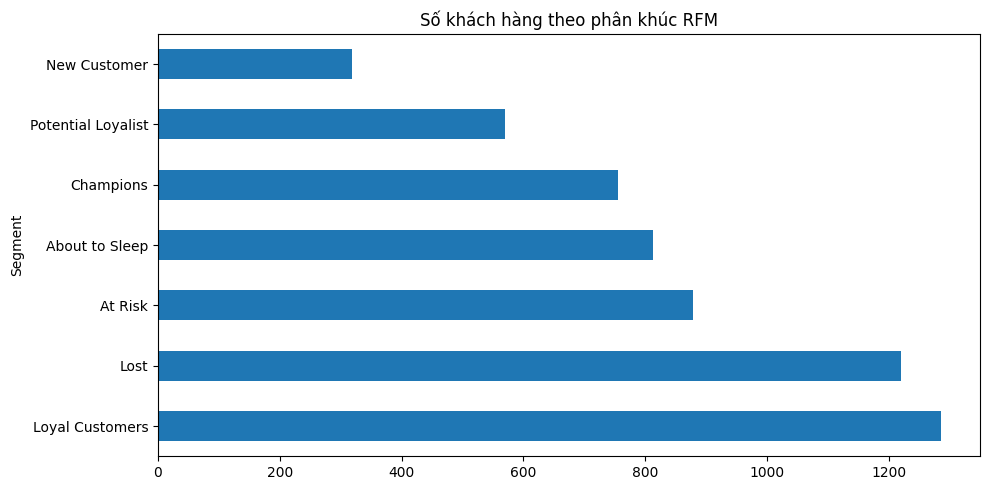

In [ ]:
# Quy mô từng phân khúc
plt.figure(figsize=(10,5))
bang_rfm['Segment'].value_counts().plot(kind='barh')
plt.title('Số khách hàng theo phân khúc RFM')
plt.tight_layout()
plt.show()

<Axes: ylabel='Segment'>

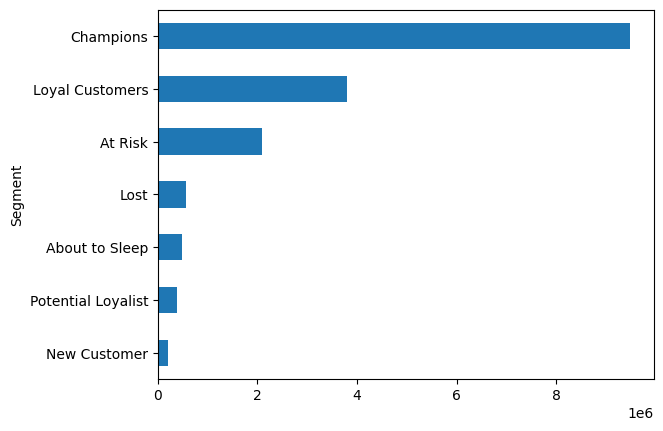

In [ ]:
# Doanh thu đóng góp theo phân khúc - thấy Pareto bằng mắt
bang_rfm.groupby('Segment')['Monetary'].sum().sort_values().plot(kind='barh')

In [ ]:
# Tạo bảng phân khúc--> hành động
# Quy mô thật từng phân khúc
quy_mo = bang_rfm.groupby('Segment').agg(
    So_khach =('Recency','size'),
    Tong_tien = ('Monetary','sum')

).round(0)
quy_mo

,So_khach,Tong_tien
Segment,,
About to Sleep,812,493786.0
At Risk,878,2082733.0
Champions,755,9487894.0
Lost,1219,558119.0
Loyal Customers,1285,3797903.0
New Customer,318,203509.0
Potential Loyalist,569,389285.0


In [ ]:
# Từ điển hành động --> map vào theo index
hanh_dong = {
    'Champions':'Chăm sóc VIP, giới thiệu sản phẩm mới',
    'Loyal Customers':'Chương trình tích điểm, giữ nhịp',
    'New Customer':'Email chào mừng, xây thói quen',
    'Potential Loyalist':'Ưu đãi mua lần thứ 2,3',
    'At Risk':'Win-back có ưu đãi,khảo sát lý do',
    'About to Sleep':'Nhắc nhẹ, nội dung tái kích hoạt',
    'Lost':'Chi phí tối thiểu, không đầu tư thêm'
}
quy_mo['Hành động đề xuất'] = quy_mo.index.map(hanh_dong)
quy_mo

,So_khach,Tong_tien,Hành động đề xuất
Segment,,,
About to Sleep,812,493786.0,"Nhắc nhẹ, nội dung tái kích hoạt"
At Risk,878,2082733.0,"Win-back có ưu đãi,khảo sát lý do"
Champions,755,9487894.0,"Chăm sóc VIP, giới thiệu sản phẩm mới"
Lost,1219,558119.0,"Chi phí tối thiểu, không đầu tư thêm"
Loyal Customers,1285,3797903.0,"Chương trình tích điểm, giữ nhịp"
New Customer,318,203509.0,"Email chào mừng, xây thói quen"
Potential Loyalist,569,389285.0,"Ưu đãi mua lần thứ 2,3"


In [ ]:
# Sắp xếp theo tổng tiền - đề xuất quan trọng nhất lên đầu
quy_mo = quy_mo.sort_values('Tong_tien', ascending= False)
quy_mo

,So_khach,Tong_tien,Hành động đề xuất
Segment,,,
Champions,755,9487894.0,"Chăm sóc VIP, giới thiệu sản phẩm mới"
Loyal Customers,1285,3797903.0,"Chương trình tích điểm, giữ nhịp"
At Risk,878,2082733.0,"Win-back có ưu đãi,khảo sát lý do"
Lost,1219,558119.0,"Chi phí tối thiểu, không đầu tư thêm"
About to Sleep,812,493786.0,"Nhắc nhẹ, nội dung tái kích hoạt"
Potential Loyalist,569,389285.0,"Ưu đãi mua lần thứ 2,3"
New Customer,318,203509.0,"Email chào mừng, xây thói quen"


In [ ]:
# Sinh bảng markdown - dán vào ô text
print(quy_mo.to_markdown())

| Segment            |   So_khach |        Tong_tien | Hành động đề xuất                     |
|:-------------------|-----------:|-----------------:|:--------------------------------------|
| Champions          |        755 |      9.48789e+06 | Chăm sóc VIP, giới thiệu sản phẩm mới |
| Loyal Customers    |       1285 |      3.7979e+06  | Chương trình tích điểm, giữ nhịp      |
| At Risk            |        878 |      2.08273e+06 | Win-back có ưu đãi,khảo sát lý do     |
| Lost               |       1219 | 558119           | Chi phí tối thiểu, không đầu tư thêm  |
| About to Sleep     |        812 | 493786           | Nhắc nhẹ, nội dung tái kích hoạt      |
| Potential Loyalist |        569 | 389285           | Ưu đãi mua lần thứ 2,3                |
| New Customer       |        318 | 203509           | Email chào mừng, xây thói quen        |


BẢNG HÀNH ĐỘNG ĐỀ XUẤT

| Segment            |   So_khach |        Tong_tien | Hành động đề xuất                     |
|:-------------------|-----------:|-----------------:|:--------------------------------------|
| Champions          |        755 |      9.48789e+06 | Chăm sóc VIP, giới thiệu sản phẩm mới |
| Loyal Customers    |       1285 |      3.7979e+06  | Chương trình tích điểm, giữ nhịp      |
| At Risk            |        878 |      2.08273e+06 | Win-back có ưu đãi,khảo sát lý do     |
| Lost               |       1219 | 558119           | Chi phí tối thiểu, không đầu tư thêm  |
| About to Sleep     |        812 | 493786           | Nhắc nhẹ, nội dung tái kích hoạt      |
| Potential Loyalist |        569 | 389285           | Ưu đãi mua lần thứ 2,3                |
| New Customer       |        318 | 203509           | Email chào mừng, xây thói quen        |
